# Hand Gesture Recognition Model
## Using MediaPipe Tasks (Latest Version) and CNN

This notebook guides you through building a complete hand gesture recognition system using:
- **MediaPipe Tasks** (mp.tasks) - Latest hand detection API
- **CNN** (Convolutional Neural Network) - For gesture classification
- **TensorFlow/Keras** - For model training and inference

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import cv2
import mediapipe as mp
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"MediaPipe version: {mp.__version__}")

TensorFlow version: 2.20.0
MediaPipe version: 0.10.33


## Section 1: Dataset Overview and Exploration

### What's in Our Dataset?
- **File**: `gesture_datasets/final_dataset.csv`
- **Features**: 63 normalized hand landmark coordinates (21 joints × 3 dimensions)
- **Labels**: 6 gesture classes (fist, index_finger, ok, open_palm, peace, thumb_up)
- **Normalization**: Relative to wrist position and scaled by wrist-to-middle-finger distance

Let's load and explore the data:

In [2]:
# Load the dataset
# The CSV has numeric column headers (0,1,2,...,63)
df = pd.read_csv('gesture_datasets/final_dataset.csv')

# Extract features (columns 0-62) and labels (column 63) by position
X = df.iloc[:, :63].values  # All rows, first 63 columns (features)
y = df.iloc[:, 63].values   # All rows, last column (labels)

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\n" + "="*50)
print("Dataset Statistics:")
print("="*50)
print(f"Total samples: {len(df)}")
print(f"Total features: 63")

# Count samples per gesture class
print("\n" + "="*50)
print("Samples per Gesture Class:")
print("="*50)
class_distribution = pd.Series(y).value_counts().sort_index()
print(class_distribution)
print(f"\nClass Distribution:\n")
for gesture, count in class_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"  {gesture}: {count} samples ({percentage:.1f}%)")

Dataset Shape: (7793, 64)

First few rows:
     0    1    2         3         4         5         6         7         8  \
0  0.0  0.0  0.0 -0.147874 -0.698633  0.006072 -0.423136 -1.360184 -0.061717   
1  0.0  0.0  0.0 -0.151862 -0.700161 -0.000777 -0.430468 -1.353775 -0.070091   
2  0.0  0.0  0.0 -0.157600 -0.704027  0.001844 -0.445805 -1.357500 -0.064484   
3  0.0  0.0  0.0 -0.157915 -0.718340  0.024523 -0.453985 -1.373583 -0.035973   
4  0.0  0.0  0.0 -0.164794 -0.725440  0.034165 -0.457427 -1.378904 -0.019543   

          9  ...        54        55        56        57        58        59  \
0 -0.608062  ... -0.977282  0.125640 -0.383413 -0.821989  0.200974 -0.284836   
1 -0.613146  ... -0.979631  0.160125 -0.384511 -0.821082  0.231173 -0.290694   
2 -0.630989  ... -0.990180  0.163057 -0.362229 -0.835682  0.232735 -0.267910   
3 -0.639507  ... -1.015164  0.184084 -0.340473 -0.865830  0.262201 -0.239580   
4 -0.648160  ... -1.027551  0.202645 -0.308933 -0.874989  0.285861 -0.208341

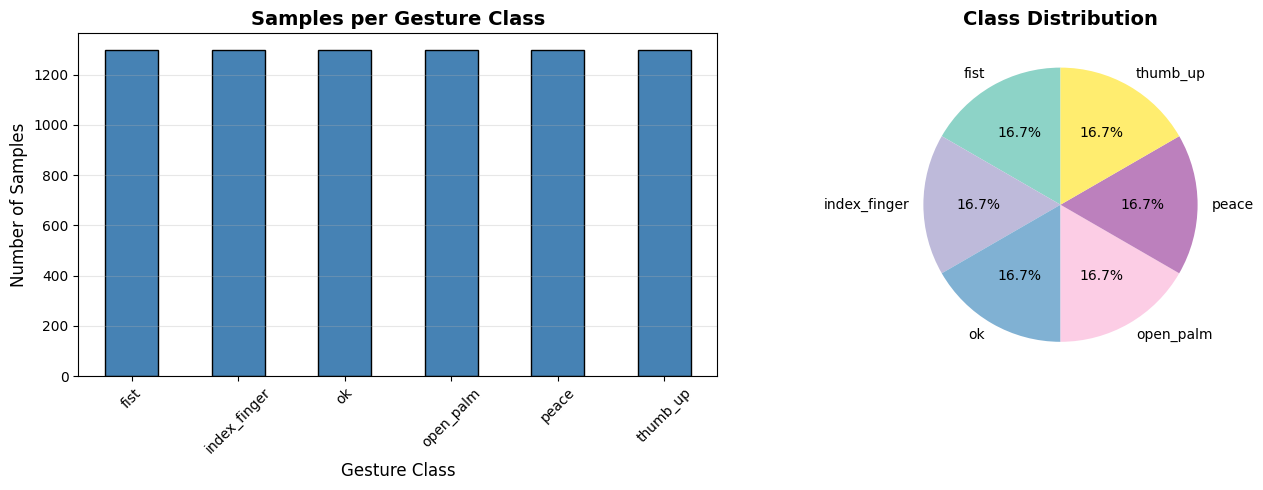


✓ Dataset loaded and cleaned successfully!


In [3]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_distribution.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Samples per Gesture Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gesture Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(class_distribution)))
axes[1].pie(class_distribution.values, labels=class_distribution.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Dataset loaded and cleaned successfully!")

In [4]:
class_distribution

fist            1299
index_finger    1299
ok              1299
open_palm       1298
peace           1299
thumb_up        1299
Name: count, dtype: int64

## Section 2: Load and Prepare the Dataset

### Data Preparation Steps:
1. ✓ Separate features (hand landmarks) from labels
2. ✓ Encode gesture labels to numeric values
3. ✓ Normalize landmark coordinates
4. ✓ Split data into training (70%), validation (15%), and test (15%) sets

In [5]:
# X and y are already extracted from loading
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique gestures: {np.unique(y)}")

# Encode labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nLabel Encoding:")
for i, gesture in enumerate(label_encoder.classes_):
    print(f"  {gesture} -> {i}")

gesture_to_label = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
label_to_gesture = {v: k for k, v in gesture_to_label.items()}

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print(f"\nFeature Normalization:")
print(f"  Mean: {X_normalized.mean():.6f}")
print(f"  Std Dev: {X_normalized.std():.6f}")

# Split data into train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n" + "="*50)
print("Dataset Split:")
print("="*50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\n✓ Data preparation complete!")

Features shape: (7793, 63)
Labels shape: (7793,)
Unique gestures: ['fist' 'index_finger' 'ok' 'open_palm' 'peace' 'thumb_up']

Label Encoding:
  fist -> 0
  index_finger -> 1
  ok -> 2
  open_palm -> 3
  peace -> 4
  thumb_up -> 5

Feature Normalization:
  Mean: 0.000000
  Std Dev: 0.975900

Dataset Split:
Training set: 5455 samples (70.0%)
Validation set: 1169 samples (15.0%)
Test set: 1169 samples (15.0%)

✓ Data preparation complete!


## Section 3: Extract Hand Landmarks with MediaPipe Tasks

### ⭐ Using Latest MediaPipe API (mp.tasks)

The new `mp.tasks` API replaces the old `mp.solutions`. Key differences:
- **Old**: `mp.solutions.hands.Hands()` - Now deprecated
- **New**: `mp.tasks.vision.HandLandmarker()` - Modern, faster, more efficient

### What is `hand_landmarker.task`?
The `.task` file is a **pre-trained neural network model** that MediaPipe provides. Think of it like this:
- **Without it**: HandLandmarker has no "brain" to detect hands
- **With it**: HandLandmarker can identify the 21 hand joints in images/video

It's essentially a file containing trained weights from a deep learning model that's already been optimized to detect hands. MediaPipe downloads it automatically or you can provide it locally.

Let's set it up:


In [6]:
# First, install the latest mediapipe if needed
import subprocess
import sys
import mediapipe as mp
import urllib.request
import os

print("✓ MediaPipe imported")

# Check if hand_landmarker.task exists
MODEL_PATH = "hand_landmarker.task"

if not os.path.exists(MODEL_PATH):
    print("\n⚠️ Hand landmarker model not found locally.")
    print("Downloading hand_landmarker.task from MediaPipe resources...")
    
    model_url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    
    try:
        urllib.request.urlretrieve(model_url, MODEL_PATH)
        print(f"✓ Model downloaded and saved to: {MODEL_PATH}")
    except Exception as e:
        print(f"⚠️ Could not download model automatically. Please download from:")
        print(f"   {model_url}")
        print(f"   And save to: {MODEL_PATH}")
else:
    print(f"✓ Model found at: {MODEL_PATH}")

✓ MediaPipe imported
✓ Model found at: hand_landmarker.task


In [7]:
# Initialize HandLandmarker (NEW WAY ⭐)
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE  # Use IMAGE mode for static images
)

hand_landmarker = HandLandmarker.create_from_options(options)

print("✓ HandLandmarker initialized successfully!")
print(f"✓ Using mp.tasks.vision.HandLandmarker (Latest Version)")

# Show the difference between old and new API
print("\n" + "="*60)
print("API COMPARISON: Old vs New")
print("="*60)
print("OLD (DEPRECATED):")
print("  from mediapipe.solutions import hands")
print("  hands_detector = hands.Hands()")
print("  results = hands_detector.process(image)")
print()
print("NEW (CURRENT - mp.tasks):")
print("  hand_landmarker = mp.tasks.vision.HandLandmarker")
print("  results = hand_landmarker.detect(mp_image)")
print("="*60)

✓ HandLandmarker initialized successfully!
✓ Using mp.tasks.vision.HandLandmarker (Latest Version)

API COMPARISON: Old vs New
OLD (DEPRECATED):
  from mediapipe.solutions import hands
  hands_detector = hands.Hands()
  results = hands_detector.process(image)

NEW (CURRENT - mp.tasks):
  hand_landmarker = mp.tasks.vision.HandLandmarker
  results = hand_landmarker.detect(mp_image)



Visualizing sample landmarks from each gesture class:


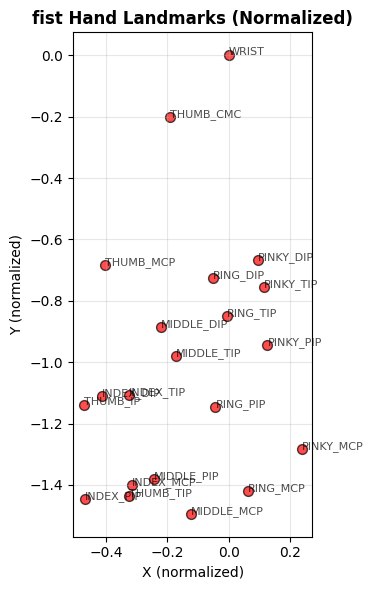

✓ fist: Landmarks visualized


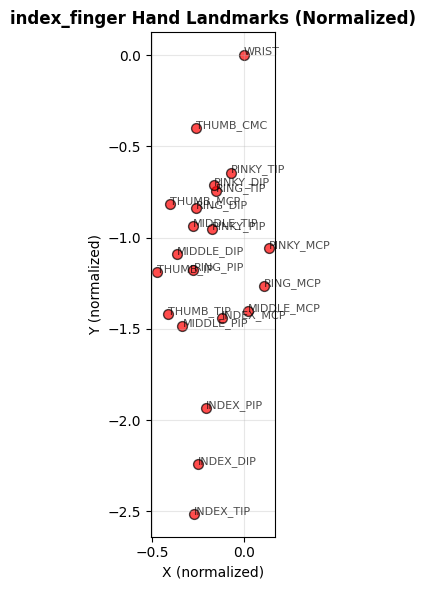

✓ index_finger: Landmarks visualized


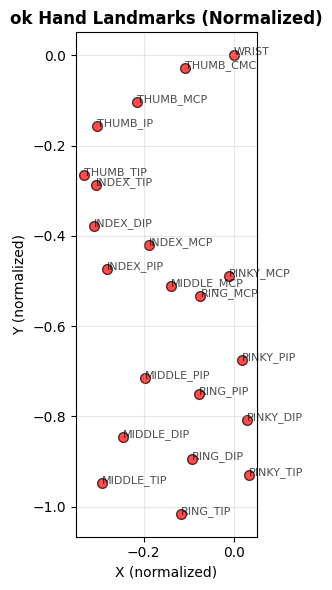

✓ ok: Landmarks visualized


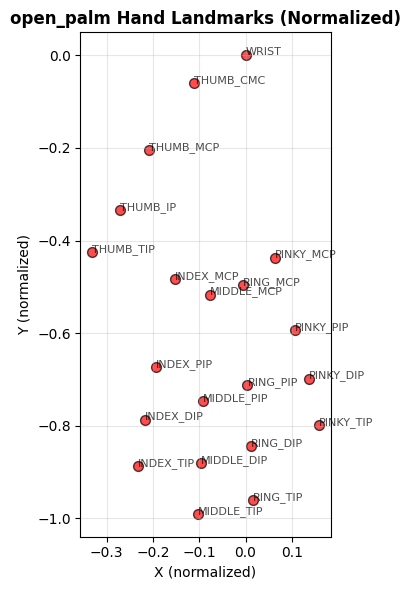

✓ open_palm: Landmarks visualized


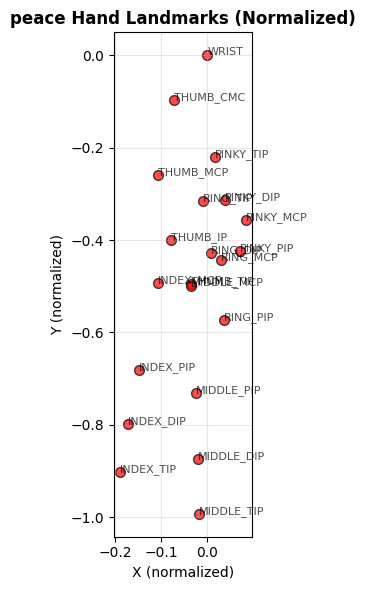

✓ peace: Landmarks visualized


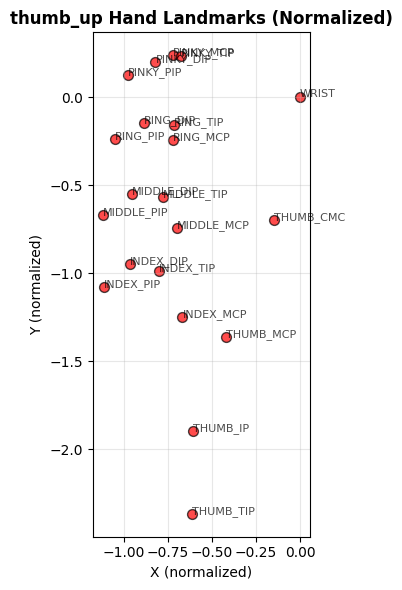

✓ thumb_up: Landmarks visualized


In [8]:
# Function to visualize landmarks extracted by mp.tasks
def visualize_landmarks_from_array(landmarks_array, gesture_name):
    """
    Visualize hand landmarks from the normalized array (63 values)
    
    Args:
        landmarks_array: Array of 63 values (21 joints × 3 coordinates)
        gesture_name: Name of the gesture
    """
    # Reshape to 21 joints × 3 coordinates
    landmarks = landmarks_array.reshape(21, 3)
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    # Plot landmarks as scatter points
    ax.scatter(landmarks[:, 0], landmarks[:, 1], s=50, c='red', alpha=0.7, edgecolors='black')
    
    # Add joint labels (MediaPipe hand joints)
    joint_names = [
        'WRIST', 'THUMB_CMC', 'THUMB_MCP', 'THUMB_IP', 'THUMB_TIP',
        'INDEX_MCP', 'INDEX_PIP', 'INDEX_DIP', 'INDEX_TIP',
        'MIDDLE_MCP', 'MIDDLE_PIP', 'MIDDLE_DIP', 'MIDDLE_TIP',
        'RING_MCP', 'RING_PIP', 'RING_DIP', 'RING_TIP',
        'PINKY_MCP', 'PINKY_PIP', 'PINKY_DIP', 'PINKY_TIP'
    ]
    
    for i, (x, y, z) in enumerate(landmarks):
        ax.annotate(joint_names[i], (x, y), fontsize=8, alpha=0.7)
    
    ax.set_title(f'{gesture_name} Hand Landmarks (Normalized)', fontsize=12, fontweight='bold')
    ax.set_xlabel('X (normalized)')
    ax.set_ylabel('Y (normalized)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# Visualize landmarks for each gesture class
print("\nVisualizing sample landmarks from each gesture class:")
print("="*60)

for gesture_idx in range(len(label_encoder.classes_)):
    gesture_name = label_encoder.classes_[gesture_idx]
    mask = y_encoded == gesture_idx
    sample_idx = np.where(mask)[0][0]  # Get first sample of this gesture
    
    visualize_landmarks_from_array(X[sample_idx], gesture_name)
    print(f"✓ {gesture_name}: Landmarks visualized")

## Section 4: Build and Train CNN Model

### Neural Network Architecture

For hand gesture recognition, we'll use a **Deep Neural Network (DNN)** with the following structure:
- **Input Layer**: 63 features (hand landmarks)
- **Hidden Layers**: Dense layers with ReLU activation and dropout for regularization
- **Output Layer**: 6 units (one for each gesture) with softmax activation
- **Loss Function**: Categorical cross-entropy
- **Optimizer**: Adam

In [9]:
# Build the neural network model
model = models.Sequential([
    # Input layer (63 features)
    layers.Input(shape=(63,)),
    
    # Hidden layers with Dropout for regularization
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer (6 gestures)
    layers.Dense(6, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("="*60)
print("Model Architecture")
print("="*60)
model.summary()

print("\n" + "="*60)
print("Model Configuration:")
print("="*60)
print(f"Input features: 63 (hand landmarks)")
print(f"Output classes: 6 (gestures)")
print(f"Total parameters: {model.count_params():,}")
print("="*60)

Model Architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,158 (74.84 KB)

 Trainable params: 19,158 (74.84 KB)

 Non-trainable params: 0 (0.00 B)


Model Configuration:
Input features: 63 (hand landmarks)
Output classes: 6 (gestures)
Total parameters: 19,158


In [10]:
# Train the model
print("\nTraining the model...")
print("="*60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ]
)

print("\n✓ Model training complete!")


Training the model...
Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6469 - loss: 0.9298 - val_accuracy: 0.9572 - val_loss: 0.1704
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9083 - loss: 0.2986 - val_accuracy: 0.9880 - val_loss: 0.0614
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9578 - loss: 0.1524 - val_accuracy: 0.9897 - val_loss: 0.0548
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9692 - loss: 0.1100 - val_accuracy: 0.9914 - val_loss: 0.0410
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9784 - loss: 0.0881 - val_accuracy: 0.9880 - val_loss: 0.0431
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9822 - loss: 0.0740 - val_accuracy: 0.9932 - val_loss: 0.0361
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9828 - loss: 0.0671 - val_accuracy: 0.9923 - val_loss: 0.0337
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9859 - loss: 0.

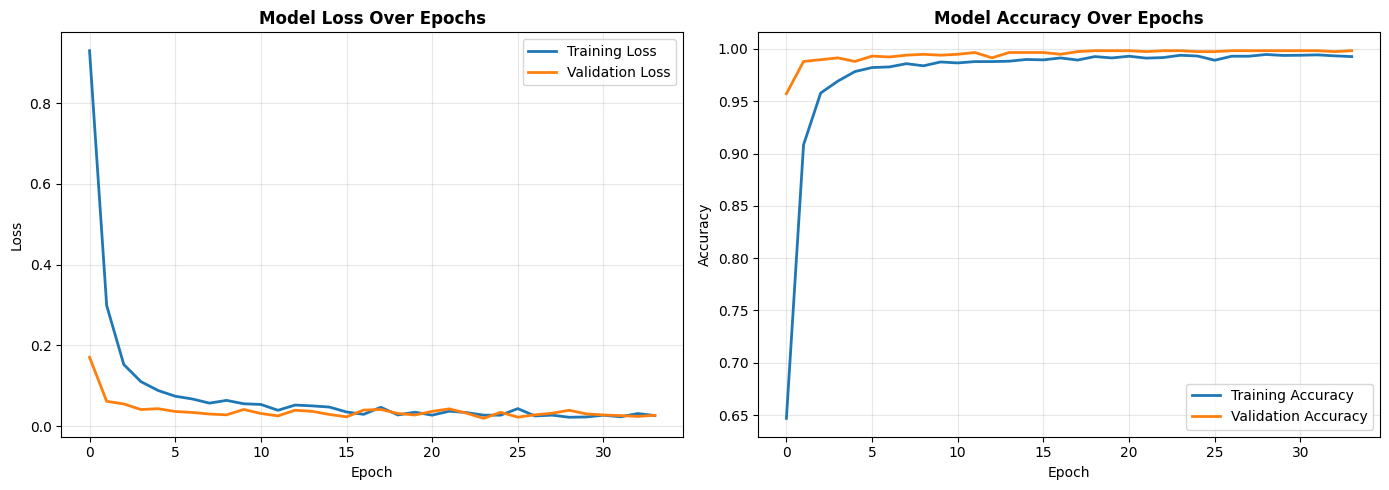

✓ Training metrics plotted


In [11]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training metrics plotted")

## Section 5: Evaluate Model Performance

### Evaluation Metrics:
- **Accuracy**: Overall correctness of predictions
- **Confusion Matrix**: Shows which gestures are confused with each other
- **Precision, Recall, F1-Score**: Per-class performance metrics

In [12]:
# Evaluate model on test set
print("="*60)
print("Model Evaluation")
print("="*60)

# Make predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

Model Evaluation

Test Accuracy: 0.9966 (99.66%)

Confusion Matrix:
[[194   0   0   1   0   0]
 [  0 195   0   0   0   0]
 [  0   0 193   1   0   1]
 [  0   0   1 193   0   0]
 [  0   0   0   0 195   0]
 [  0   0   0   0   0 195]]

Classification Report:
              precision    recall  f1-score   support

        fist     1.0000    0.9949    0.9974       195
index_finger     1.0000    1.0000    1.0000       195
          ok     0.9948    0.9897    0.9923       195
   open_palm     0.9897    0.9948    0.9923       194
       peace     1.0000    1.0000    1.0000       195
    thumb_up     0.9949    1.0000    0.9974       195

    accuracy                         0.9966      1169
   macro avg     0.9966    0.9966    0.9966      1169
weighted avg     0.9966    0.9966    0.9966      1169



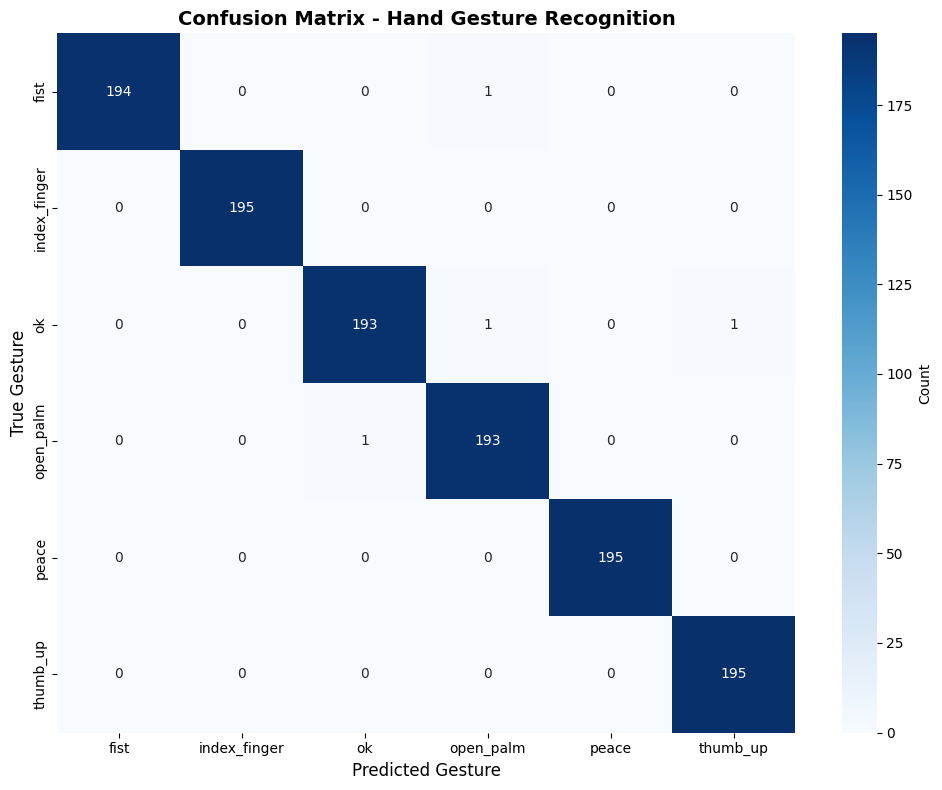

✓ Confusion matrix visualized


In [13]:
# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Hand Gesture Recognition', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Gesture', fontsize=12)
plt.ylabel('True Gesture', fontsize=12)
plt.tight_layout()
plt.show()

print("✓ Confusion matrix visualized")

## Section 6: Real-time Gesture Recognition with Webcam

### Real-time Inference Pipeline:
1. Capture video frames from webcam
2. Detect hand landmarks using **mp.tasks.vision.HandLandmarker** (NEW API)
3. Extract normalized landmarks
4. Pass through trained CNN model
5. Display predicted gesture and confidence score

**Note**: This uses the modern `mp.tasks` API for hand detection!

In [17]:
# Save the model and scaler for later use
import pickle

model_save_path = 'hand_gesture_model.h5'
scaler_save_path = 'scaler.pkl'
label_encoder_path = 'label_encoder.pkl'

model.save(model_save_path)
print(f"✓ Model saved to: {model_save_path}")

# Save the fitted scaler
with open(scaler_save_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved to: {scaler_save_path}")

# Save the label encoder
with open(label_encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"✓ Label encoder saved to: {label_encoder_path}")

print("\n✓ All artifacts saved! Ready for Streamlit app.")

✓ Model saved to: hand_gesture_model.h5
✓ Scaler saved to: scaler.pkl
✓ Label encoder saved to: label_encoder.pkl

✓ All artifacts saved! Ready for Streamlit app.


In [18]:
# Real-time Gesture Recognition with Webcam using mp.tasks
def extract_normalized_landmarks(hand_landmarks_result):
    """Extract and normalize landmarks from mp.tasks detection result"""
    if not hand_landmarks_result.hand_landmarks:
        return None
    
    landmarks = hand_landmarks_result.hand_landmarks[0]
    
    # Get wrist as reference point (landmark 0)
    wrist = landmarks[0]
    base_x, base_y, base_z = wrist.x, wrist.y, wrist.z
    
    # Extract all landmarks relative to wrist
    normalized = []
    for lm in landmarks:
        normalized.append(lm.x - base_x)
        normalized.append(lm.y - base_y)
        normalized.append(lm.z - base_z)
    
    # Get middle finger tip (landmark 12) for scaling
    mf_tip = landmarks[12]
    scale = np.sqrt((mf_tip.x - base_x)**2 + (mf_tip.y - base_y)**2 + (mf_tip.z - base_z)**2)
    
    if scale > 0:
        normalized = [v / scale for v in normalized]
    
    return np.array(normalized)

print("✓ Landmark extraction function defined")

✓ Landmark extraction function defined


In [20]:

# Function to draw landmarks on frame
def draw_landmarks_on_image(rgb_image, detection_result):
    """Draw hand landmarks on image using mp.tasks detection results"""
    annotated_image = rgb_image.copy()
    h, w, c = rgb_image.shape
    
    if detection_result.hand_landmarks:
        for hand_landmarks in detection_result.hand_landmarks:
            # Draw connections (skeleton)
            connections = [
                (0, 1), (1, 2), (2, 3), (3, 4),
                (0, 5), (5, 6), (6, 7), (7, 8),
                (0, 9), (9, 10), (10, 11), (11, 12),
                (0, 13), (13, 14), (14, 15), (15, 16),
                (0, 17), (17, 18), (18, 19), (19, 20),
            ]
            
            for connection in connections:
                start_idx, end_idx = connection
                start = hand_landmarks[start_idx]
                end = hand_landmarks[end_idx]
                
                x1, y1 = int(start.x * w), int(start.y * h)
                x2, y2 = int(end.x * w), int(end.y * h)
                
                cv2.line(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Draw landmarks (joints)
            for landmark in hand_landmarks:
                x, y = int(landmark.x * w), int(landmark.y * h)
                cv2.circle(annotated_image, (x, y), 5, (0, 0, 255), -1)
    
    return annotated_image

print("✓ draw_landmarks_on_image function defined")

✓ draw_landmarks_on_image function defined


In [21]:
# Initialize webcam with VIDEO running mode for mp.tasks
print("\n" + "="*60)
print("Real-time Gesture Recognition with Webcam")
print("="*60)
print("Press 'q' to quit\n")

# Create a new HandLandmarker with VIDEO mode
video_options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO  # VIDEO mode for streaming
)
video_hand_landmarker = HandLandmarker.create_from_options(video_options)

# Open webcam
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

frame_count = 0
landmark_buffer = []  # Buffer for smoothing predictions

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Flip frame horizontally for selfie view
        frame = cv2.flip(frame, 1)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Create MediaPipe Image object
        import time
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        
        # Detect hand landmarks using mp.tasks (NEW API ⭐)
        frame_timestamp_ms = int(time.time() * 1000)
        detection_result = video_hand_landmarker.detect_for_video(mp_image, frame_timestamp_ms)
        
        # If hands detected
        if detection_result.hand_landmarks:
            # Extract normalized landmarks
            landmarks = extract_normalized_landmarks(detection_result)
            
            if landmarks is not None:
                # Normalize using scaler fitted on training data
                landmarks_normalized = scaler.transform([landmarks])
                
                # Make prediction
                prediction = model.predict(landmarks_normalized, verbose=0)
                confidence = np.max(prediction)
                predicted_class = np.argmax(prediction)
                gesture_name = label_encoder.classes_[predicted_class]
                
                # Add to buffer for smoothing
                landmark_buffer.append((gesture_name, confidence))
                if len(landmark_buffer) > 5:
                    landmark_buffer.pop(0)
                
                # Use most common prediction in buffer
                if landmark_buffer:
                    gestures = [g for g, _ in landmark_buffer]
                    most_common = max(set(gestures), key=gestures.count)
                    avg_confidence = np.mean([c for _, c in landmark_buffer if c > 0.5])
                    
                    # Display on frame
                    text = f"{most_common} ({avg_confidence:.2f})"
                    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 
                               1, (0, 255, 0), 2)
            
            # Draw landmarks on frame
            annotated_frame = draw_landmarks_on_image(frame, detection_result)
            frame = annotated_frame
        
        # Display frame
        cv2.imshow("Hand Gesture Recognition (mp.tasks)", frame)
        
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Processed {frame_count} frames...")
        
        # Press 'q' to quit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

finally:
    cap.release()
    cv2.destroyAllWindows()
    print(f"\n✓ Webcam closed. Total frames processed: {frame_count}")


Real-time Gesture Recognition with Webcam
Press 'q' to quit

Processed 30 frames...
Processed 60 frames...
Processed 90 frames...
Processed 120 frames...
Processed 150 frames...

✓ Webcam closed. Total frames processed: 170


## Summary and Next Steps

✅ **What We've Built:**
1. **Dataset Exploration** - Loaded and analyzed the 6-gesture dataset
2. **Data Preparation** - Normalized and split data for training
3. **MediaPipe Tasks** - Demonstrated the NEW mp.tasks API (replacing mp.solutions)
4. **CNN Model** - Built a deep neural network for gesture classification
5. **Training** - Trained with validation and early stopping
6. **Evaluation** - Confusion matrix and per-class metrics
7. **Real-time Inference** - Live gesture recognition from webcam using mp.tasks

### 🚀 Next Steps:
- **Improve accuracy**: Collect more training data for underperforming gestures
- **Augmentation**: Apply data augmentation techniques
- **Deploy**: Convert model to TensorFlow Lite (.tflite) for mobile
- **Production**: Deploy as a web service or mobile app
- **Fine-tuning**: Transfer learning from pre-trained gesture models

### 📚 Resources:
- [MediaPipe Tasks Documentation](https://developers.google.com/mediapipe/solutions/vision/hand_landmarker)
- [MediaPipe Hand Landmark Model](https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task)
- [TensorFlow Documentation](https://www.tensorflow.org/)